In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Class Distribution:
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64


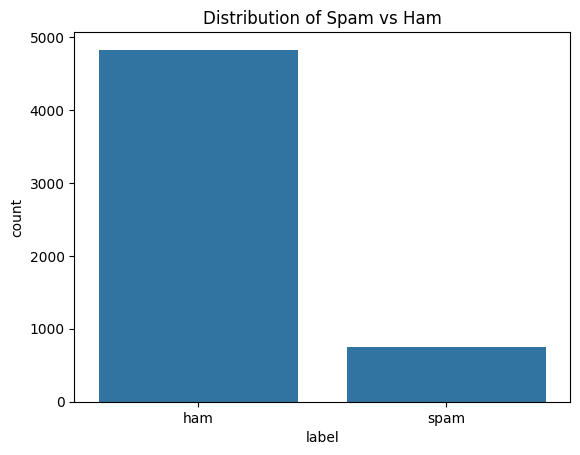

In [8]:
import pandas as pd
import requests
import io
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
response = requests.get(url)

df = pd.read_csv(io.StringIO(response.text), sep="\t", names=["label", "message"])

display(df.head())

print("\nClass Distribution:")
print(df["label"].value_counts(normalize=True))

sns.countplot(x="label", data=df)
plt.title("Distribution of Spam vs Ham")
plt.show()

In [12]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess_text)
display(df[['message', 'clean_message']].head())

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [13]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_message'], df['label_num'], test_size=0.2, random_state=42, stratify=df['label_num']
)

def evaluate_model(vectorizer, alpha_list, X_train_raw, X_test_raw, y_train, y_test, name):
    results = []
    X_train = vectorizer.fit_transform(X_train_raw)
    X_test = vectorizer.transform(X_test_raw)

    for alpha in alpha_list:
        nb = MultinomialNB(alpha=alpha)
        nb.fit(X_train, y_train)
        y_pred = nb.predict(X_test)
        y_prob = nb.predict_proba(X_test)[:, 1]

        res = {
            'Vectorization': name,
            'Alpha': alpha,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_prob)
        }
        results.append(res)
    return results

alphas = [0.1, 0.5, 1, 2, 5]
all_results = []

all_results.extend(evaluate_model(CountVectorizer(), alphas, X_train_raw, X_test_raw, y_train, y_test, 'CV_Unigrams'))
all_results.extend(evaluate_model(TfidfVectorizer(), alphas, X_train_raw, X_test_raw, y_train, y_test, 'TFIDF_Unigrams'))
all_results.extend(evaluate_model(CountVectorizer(ngram_range=(1, 2)), alphas, X_train_raw, X_test_raw, y_train, y_test, 'CV_Bigrams'))
all_results.extend(evaluate_model(TfidfVectorizer(ngram_range=(1, 2)), alphas, X_train_raw, X_test_raw, y_train, y_test, 'TFIDF_Bigrams'))

results_df = pd.DataFrame(all_results)
display(results_df.sort_values(by='F1-Score', ascending=False).head(10))

,Vectorization,Alpha,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CV_Unigrams,0.1,0.984753,0.971429,0.912752,0.941176,0.979421
10,CV_Bigrams,0.1,0.983857,0.964539,0.912752,0.937931,0.982812
1,CV_Unigrams,0.5,0.983857,0.971223,0.906040,0.937500,0.981054
2,CV_Unigrams,1.0,0.982063,0.970803,0.892617,0.930070,0.979199
11,CV_Bigrams,0.5,0.982063,0.977778,0.885906,0.929577,0.981603
12,CV_Bigrams,1.0,0.980269,0.977444,0.872483,0.921986,0.976434
13,CV_Bigrams,2.0,0.978475,0.977099,0.859060,0.914286,0.968138
15,TFIDF_Bigrams,0.1,0.978475,0.984496,0.852349,0.913669,0.990516
4,CV_Unigrams,5.0,0.978475,1.000000,0.838926,0.912409,0.961976
3,CV_Unigrams,2.0,0.977578,0.969697,0.859060,0.911032,0.974238


Best Model: CV_Unigrams with alpha=0.1


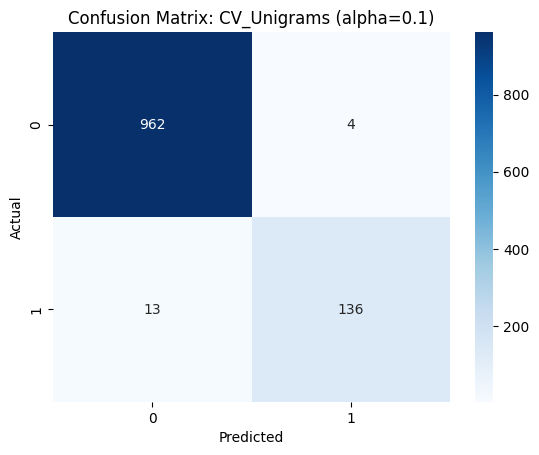

In [14]:
best_row = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"Best Model: {best_row['Vectorization']} with alpha={best_row['Alpha']}")

if 'CV' in best_row['Vectorization']:
    vect = CountVectorizer(ngram_range=(1, 2) if 'Bigrams' in best_row['Vectorization'] else (1, 1))
else:
    vect = TfidfVectorizer(ngram_range=(1, 2) if 'Bigrams' in best_row['Vectorization'] else (1, 1))

X_train = vect.fit_transform(X_train_raw)
X_test = vect.transform(X_test_raw)
model = MultinomialNB(alpha=best_row['Alpha'])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix: {best_row["Vectorization"]} (alpha={best_row["Alpha"]})')
plt.show()